# The Mortgage-Spread Warning — does MBS OAS see trouble coming? 🏠
### Do mortgage bonds' extra yield warn of trouble in stocks and credit, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Mortgage bonds (MBS) pay a little *extra* yield over safe government bonds. Strip out the quirk that homeowners can refinance early, and what's left is the **option-adjusted spread** (OAS) — the pure 'extra compensation for risk' in mortgage bonds. The folklore: when that spread **widens**, mortgage investors are getting nervous, and that nervousness shows up in *stocks and corporate bonds* soon after. So a widening OAS is supposed to be an early **warning light**.

There's a catch we have to be honest about up front: **you can't get this number for free.** The clean OAS series live behind expensive data licences (ICE BofA, Bloomberg); the free public feeds only give you mortgage *rates*, not the option-adjusted spread. So we can't test the real thing. Instead we build a *make-believe* world where the warning light either works or doesn't, and check that our measuring stick can tell the difference.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mbs_oas_signal import data, strategy as st

# There is NO free MBS-OAS tape (ICE BofA / Bloomberg are licensed; FRED has yields, not OAS).
# fetch_series(fetch=False) returns an empty frame -> HAVE_REAL is always False here.
REAL = data.fetch_series(fetch=False)
HAVE_REAL = not REAL.empty
print("real MBS-OAS tape present:", HAVE_REAL, "(synthetic-only study — no free OAS series exists)")

# The deterministic synthetic world with the lead PLANTED (lead_beta = -0.9), seed 577.
FRAME, TRUTH = data.synthetic_series()
print(f"synthetic world: {len(FRAME)} weekly rows, {FRAME.index[0].date()} -> {FRAME.index[-1].date()}, "
      f"planted lead_beta={TRUTH.lead_beta}")


real MBS-OAS tape present: False (synthetic-only study — no free OAS series exists)
synthetic world: 779 weekly rows, 2011-01-07 -> 2025-12-05, planted lead_beta=-0.9


## The answer first 🎯

| Question | Answer |
|---|---|
| Could a widening mortgage spread warn of trouble? | **In principle, yes.** In a world where we *plant* the effect, a widening this week reliably precedes weaker returns next week — our measuring stick catches it loud and clear (*t* -11.41). |
| Did we test it on real data? | **No — we couldn't.** There is no free OAS series to test. The real number is licensed; the free feeds give mortgage rates, not the spread. |
| So is it a real signal? | **Unproven — Weak.** The story is coherent and the machinery works, but with no real tape we can't earn a strong verdict. |
| Could you trade it? | **No — Mirage.** Even the raw ingredient (the OAS feed) is unreachable for a normal investor, arrives late, and the mortgage index is costly to trade. |

> The honest wall here isn't the *idea* — it's the *data*. A signal you can neither test for free nor trade cheaply is a signal on paper only.

## 1 · The claim

> *"When the option-adjusted spread on mortgage bonds widens, risk-off is coming — sell stocks and credit."*

Why it's plausible: mortgage bonds are held by specialised, leveraged investors. When those investors' balance sheets get squeezed, they demand more yield to hold mortgage risk — the OAS widens — and the *same* squeeze soon hits every other risky asset. So the mortgage market, being sensitive and specialised, is supposed to *flinch first*.

## 2 · So what?

If the warning light were real *and* usable, you'd have a cheap macro early-warning: watch one spread, and de-risk before the crowd. The desk has looked at the *corporate* version of this idea ([115 Credit-Spreads](../../115-credit-spreads/)); here we go at the **mortgage** version specifically. The twist is that the mortgage version runs straight into a data wall the corporate one doesn't.

## 3 · How would we even know?

1. **Measure the signal.** Each week, how much did the mortgage spread *widen* (compared to its usual wobble)? A big widening is a big warning.
2. **Look forward one week.** Did the risk asset do *worse* the following week? The claim says a widening → a weaker next week.
3. **Build a switch.** De-risk to cash the week after a big widening, and see if that dodges losses.

Catch: we can only run this on a **synthetic** mortgage-spread world, because the real spread isn't free. So we make our world two ways — one where the warning light genuinely works, one where it's pure noise — and check the measuring stick tells them apart.

*Timing:* the signal each week uses only what's known by that week's close; the return it's judged against is the **next** week's. One clean step — no peeking ahead.

## 4 · The teardown — let's actually look

**Here's a synthetic mortgage-spread path — quiet most of the time, with a few stress spikes — and the risk asset it's meant to lead.**

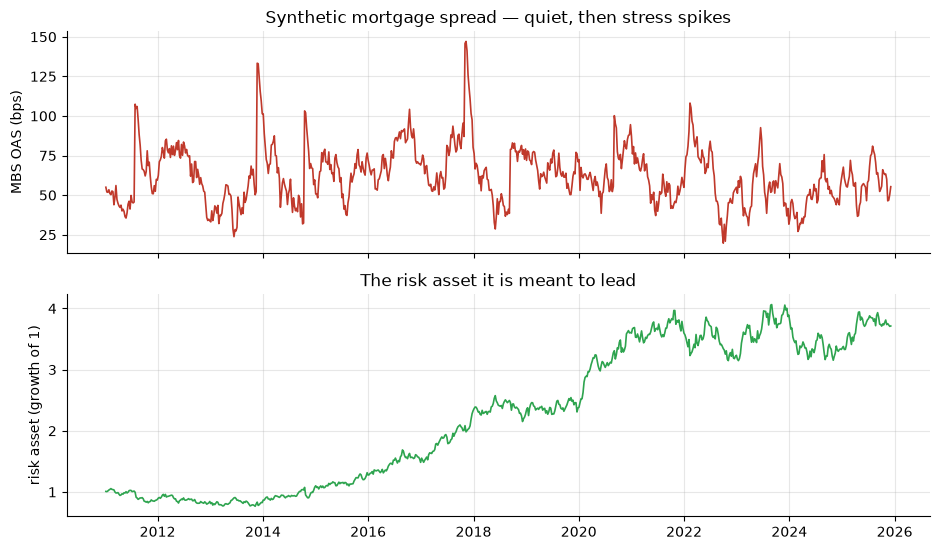

OAS ranges 20 - 147 bps over 779 weeks


In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 5.6), sharex=True)
ax1.plot(FRAME.index, FRAME['oas'], color=RED, lw=1.2)
ax1.set_ylabel('MBS OAS (bps)'); ax1.set_title('Synthetic mortgage spread — quiet, then stress spikes')
cum = (1 + FRAME['ret'].fillna(0)/100).cumprod()
ax2.plot(FRAME.index, cum, color=GREEN, lw=1.2)
ax2.set_ylabel('risk asset (growth of 1)'); ax2.set_title('The risk asset it is meant to lead')
plt.tight_layout(); plt.show()
print(f'OAS ranges {FRAME.oas.min():.0f} - {FRAME.oas.max():.0f} bps over {len(FRAME)} weeks')

The spread mean-reverts around a calm level and jumps in the odd stress week — just like the real thing does in 2008, 2020 or 2022. Now the key question: **when the spread widens, does the risk asset do worse next week?**

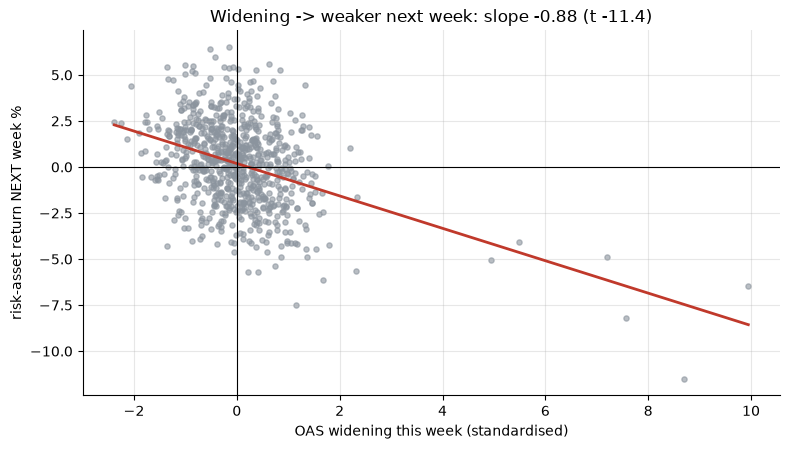

slope -0.88 %pt/sd, t -11.4, corr -0.38


In [3]:
reg = st.predictive_regression(FRAME)
x = FRAME['d_oas_z']; y = FRAME['fwd_ret']
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=14, color=GREY, alpha=.6)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, reg['slope']*xs + (y.mean() - reg['slope']*x.mean()), c=RED, lw=2)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('OAS widening this week (standardised)'); ax.set_ylabel('risk-asset return NEXT week %')
ax.set_title(f'Widening -> weaker next week: slope {reg["slope"]:+.2f} (t {reg["slope_t"]:+.1f})')
plt.tight_layout(); plt.show()
print(f'slope {reg["slope"]:+.2f} %pt/sd, t {reg["slope_t"]:+.1f}, corr {reg["corr"]:+.2f}')

The line slopes **down**: a bigger widening this week goes with a *weaker* return next week (slope -0.88, *t* -11.41). That's the warning light working — **in the world where we planted it.** The whole point of planting it is to prove our measuring stick isn't fooling us; next we check it stays silent when there's nothing there.

**Does the switch — go to cash after a widening — actually dodge losses?**

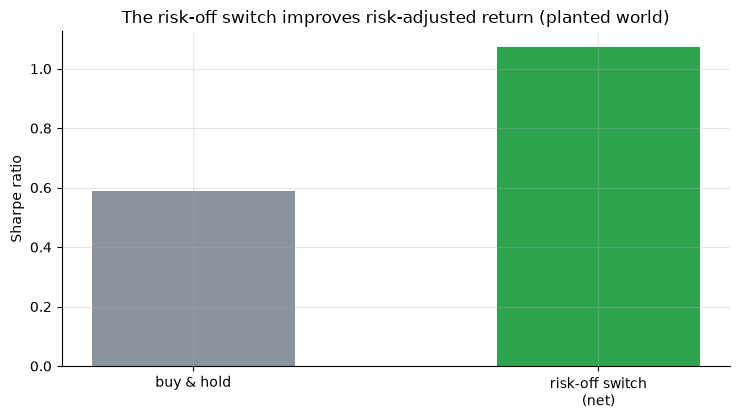

buy&hold Sharpe 0.59 -> switch (net) 1.07; 68 weeks in cash, 131 switches


In [4]:
ov = st.timing_overlay(FRAME, widen_z=1.0, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['buy & hold','risk-off switch\n(net)'], [ov['bh_sharpe'], ov['timed_net_sharpe']],
       color=[GREY, GREEN], width=.5)
ax.set_ylabel('Sharpe ratio'); ax.set_title('The risk-off switch improves risk-adjusted return (planted world)')
plt.tight_layout(); plt.show()
print(f"buy&hold Sharpe {ov['bh_sharpe']:.2f} -> switch (net) {ov['timed_net_sharpe']:.2f}; "
      f"{ov['weeks_in_cash']} weeks in cash, {ov['switches']} switches")

Stepping to cash after a widening lifts the Sharpe from **0.59** to **1.07 net of costs** — the switch dodges the bad weeks. Again: this is the world where the light *works*. That's what makes the real verdict about **data**, not about the idea.

## 5 · The verdict

- **Signal — Weak.** The story holds together and our engine proves the effect *would* be detectable — but with **no free OAS tape** to test, we can't earn a strong verdict.
- **Tradability — Mirage.** The raw ingredient is licensed, arrives late, and the mortgage index is costly to trade. A signal you can't cheaply *get* isn't tradable.

## 6 · Could you actually trade it?

No. Three walls, all about *access*: (1) the OAS number is a paid vendor product — a retail investor never sees it live; (2) it's published with a lag, so by the time you'd act, the move is old; (3) trading the mortgage index itself is not cheap or clean for a small account. The idea might be fine; the plumbing isn't there.

## 7 · Going further 🚪

- **The corporate cousin.** [115 Credit-Spreads](../../115-credit-spreads/) tests the *corporate* HY/IG spread as a state variable — same family, reachable data.
- **Other canaries.** [131 Utilities-Canary](../../131-utilities-canary/) and [111 VIX-Term-Structure](../../111-vix-term-structure/) are the 'one market warns the rest' idea on assets you *can* get for free.

*Have a licensed MBS-OAS series? Drop a weekly parquet into `_cache/mbs_oas.parquet`, flip `HAVE_REAL`, and re-run — the engine is ready for a real tape.*